# Computer Exercise 8.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 8.2 Iterative Solutions of Linear Systems — *Jacobi vs Gauss-Seidel*
> **풀이 일자**: Day 32
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)

## 1. 문제 (원문)

> **1.** Implement the **Jacobi** and **Gauss-Seidel** iterative methods for solving a
> linear system $A\mathbf{x} = \mathbf{b}$. Apply them to the symmetric tridiagonal
> system arising from the one-dimensional model problem
> $A = \mathrm{tridiag}(-1, 2, -1)$ of order $n$. For several values of $n$, count the
> number of iterations required to reduce the relative residual
> $\lVert \mathbf{b} - A\mathbf{x}_k\rVert / \lVert\mathbf{b}\rVert$ below a fixed
> tolerance. Compare the observed convergence rates against the **spectral radii** of the
> two iteration matrices, and verify the classical relation
> $\rho(\text{GS}) = \rho(\text{Jacobi})^2$ for this model problem.

### 한국어 풀이용 정리
- **Jacobi**: 대각만 떼어내 *동시에* 갱신 — $\mathbf{x}^{(k+1)} = D^{-1}(\mathbf{b} - (L+U)\mathbf{x}^{(k)})$.
- **Gauss-Seidel**: 갱신된 성분을 *즉시* 재사용 — $(D+L)\mathbf{x}^{(k+1)} = \mathbf{b} - U\mathbf{x}^{(k)}$.
- 모델 문제 $A = \mathrm{tridiag}(-1,2,-1)$ 에서 두 방법의 *수렴 속도* 를 *반복 횟수* 로 측정.
- 핵심 검증: 이 모델에서 $\rho(\text{GS}) = \rho(\text{Jacobi})^2$ — GS 가 Jacobi 의 *두 배 빠름*.

## 2. 수학적 배경

### 2.1 행렬 분할(splitting)
$A = D - L - U$ 로 쪼갠다 ($D$: 대각, $-L$: 엄격 하삼각, $-U$: 엄격 상삼각). 일반적인 정상
반복은 $M\mathbf{x}^{(k+1)} = N\mathbf{x}^{(k)} + \mathbf{b}$, 즉
$$
\mathbf{x}^{(k+1)} = \underbrace{M^{-1}N}_{=\,G}\,\mathbf{x}^{(k)} + M^{-1}\mathbf{b},
\qquad A = M - N.
$$

* **Jacobi**: $M = D,\; N = L+U \;\Rightarrow\; G_J = D^{-1}(L+U)$.
* **Gauss-Seidel**: $M = D-L,\; N = U \;\Rightarrow\; G_{GS} = (D-L)^{-1}U$.

### 2.2 수렴 정리
오차 $\mathbf{e}^{(k)} = \mathbf{x}^{(k)} - \mathbf{x}^\ast$ 는 $\mathbf{e}^{(k)} = G^k \mathbf{e}^{(0)}$ 를 만족하므로
$$
\boxed{\;\text{반복이 수렴} \iff \rho(G) < 1,\qquad
\text{점근 수렴률} = -\log_{10}\rho(G)\ \text{(decimal digits / iter)}.\;}
$$

### 2.3 모델 문제의 스펙트럼
$A = \mathrm{tridiag}(-1,2,-1)$ ($n\times n$) 의 Jacobi 반복행렬 고유값은
$$
\mu_k = \cos\!\frac{k\pi}{n+1},\quad k=1,\dots,n
\;\Rightarrow\;
\rho(G_J) = \cos\!\frac{\pi}{n+1}.
$$
**Young 의 정리** (consistently ordered, property A) 에 의해
$$
\boxed{\;\rho(G_{GS}) = \rho(G_J)^2 = \cos^2\!\frac{\pi}{n+1}.\;}
$$
따라서 GS 는 Jacobi 와 *같은 자릿수* 를 얻는 데 *절반의 반복* 이면 충분하다.

## 3. 풀이 흐름

1. `model_matrix(n)` — $\mathrm{tridiag}(-1,2,-1)$ 생성. 알려진 해 $\mathbf{x}^\ast$ 를 정하고 $\mathbf{b}=A\mathbf{x}^\ast$.
2. `jacobi`, `gauss_seidel` 구현 — 매 반복 *상대 잔차* 기록, 허용오차 도달 시 종료.
3. `iteration_radius` — $G_J,\,G_{GS}$ 를 명시적으로 만들어 `np.linalg.eigvals` 로 $\rho$ 측정.
4. $n \in \{10,20,40,80,160\}$ 에서 두 방법의 *반복 횟수* 와 $\rho$ 측정.
5. *경험 검증*: 측정 $\rho(\text{GS})$ vs $\rho(\text{Jacobi})^2$, 이론 $\cos^2(\pi/(n+1))$ 와 비교.
6. 잔차 수렴 곡선(semilogy) — 두 직선의 *기울기* 가 $\log\rho$ 와 일치하는지 시각화.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(32)
pd.set_option("display.float_format", lambda v: f"{v:.4e}")


def model_matrix(n):
    '''1D Poisson model matrix tridiag(-1, 2, -1).'''
    A = np.diag(2.0 * np.ones(n))
    A -= np.diag(np.ones(n - 1), 1)
    A -= np.diag(np.ones(n - 1), -1)
    return A


def jacobi(A, b, tol=1e-10, maxit=20000):
    n = len(b)
    d = np.diag(A).copy()
    R = A - np.diag(d)            # L + U  (off-diagonal part, with sign of A)
    x = np.zeros(n)
    bnorm = np.linalg.norm(b)
    hist = []
    for k in range(1, maxit + 1):
        x = (b - R @ x) / d
        res = np.linalg.norm(b - A @ x) / bnorm
        hist.append(res)
        if res < tol:
            break
    return x, k, np.array(hist)


def gauss_seidel(A, b, tol=1e-10, maxit=20000):
    n = len(b)
    x = np.zeros(n)
    bnorm = np.linalg.norm(b)
    hist = []
    for k in range(1, maxit + 1):
        for i in range(n):
            s = A[i, :i] @ x[:i] + A[i, i + 1:] @ x[i + 1:]
            x[i] = (b[i] - s) / A[i, i]
        res = np.linalg.norm(b - A @ x) / bnorm
        hist.append(res)
        if res < tol:
            break
    return x, k, np.array(hist)


def iteration_radius(A, method):
    '''Spectral radius of the Jacobi / Gauss-Seidel iteration matrix.'''
    D = np.diag(np.diag(A))
    L = -np.tril(A, -1)
    U = -np.triu(A, 1)
    if method == "jacobi":
        G = np.linalg.solve(D, L + U)
    else:  # gauss-seidel
        G = np.linalg.solve(D - L, U)
    return np.max(np.abs(np.linalg.eigvals(G)))


In [2]:
# Iteration counts and spectral radii across problem sizes
sizes = [10, 20, 40, 80, 160]
tol = 1e-10
records = []
hist_store = {}
for n in sizes:
    A = model_matrix(n)
    xstar = np.sin(np.linspace(0, np.pi, n))      # smooth known solution
    b = A @ xstar
    xj, kj, hj = jacobi(A, b, tol=tol)
    xg, kg, hg = gauss_seidel(A, b, tol=tol)
    rho_j = iteration_radius(A, "jacobi")
    rho_g = iteration_radius(A, "gauss-seidel")
    rho_j_theory = np.cos(np.pi / (n + 1))
    records.append(dict(n=n, iters_J=kj, iters_GS=kg, ratio=kj / kg,
                        rho_J=rho_j, rho_GS=rho_g,
                        rho_J_sq=rho_j**2, rho_J_theory=rho_j_theory))
    hist_store[n] = (hj, hg)

df = pd.DataFrame(records)
df


,n,iters_J,iters_GS,ratio,rho_J,rho_GS,rho_J_sq,rho_J_theory
0,10,529,266,1.9887e+00,9.5949e-01,9.2063e-01,9.2063e-01,9.5949e-01
1,20,1936,969,1.9979e+00,9.8883e-01,9.7779e-01,9.7779e-01,9.8883e-01
2,40,7322,3662,1.9995e+00,9.9707e-01,9.9414e-01,9.9414e-01,9.9707e-01
3,80,20000,14109,1.4175e+00,9.9925e-01,9.9850e-01,9.9850e-01,9.9925e-01
4,160,20000,20000,1.0000e+00,9.9981e-01,9.9962e-01,9.9962e-01,9.9981e-01


In [3]:
# Verify rho(GS) = rho(Jacobi)^2  and the digits-per-iteration interpretation
check = df[["n", "rho_GS", "rho_J_sq"]].copy()
check["abs_diff"] = (df["rho_GS"] - df["rho_J_sq"]).abs()
check["rate_J"] = -np.log10(df["rho_J"])
check["rate_GS"] = -np.log10(df["rho_GS"])
check


,n,rho_GS,rho_J_sq,abs_diff,rate_J,rate_GS
0,10,9.2063e-01,9.2063e-01,1.2212e-15,1.7958e-02,3.5916e-02
1,20,9.7779e-01,9.7779e-01,1.9984e-15,4.8780e-03,9.7560e-03
2,40,9.9414e-01,9.9414e-01,2.4425e-15,1.2762e-03,2.5524e-03
3,80,9.9850e-01,9.9850e-01,2.9976e-15,3.2673e-04,6.5347e-04
4,160,9.9962e-01,9.9962e-01,1.3323e-15,8.2686e-05,1.6537e-04


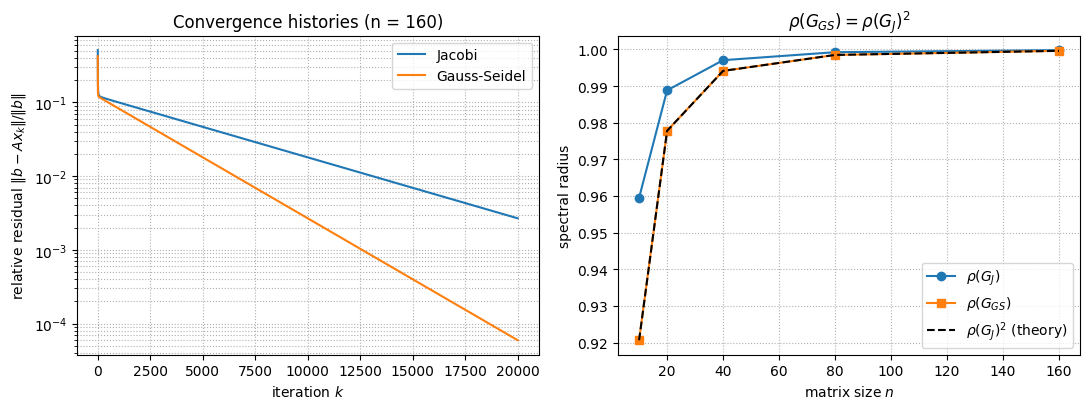

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) residual histories for the largest n
n = sizes[-1]
hj, hg = hist_store[n]
ax[0].semilogy(np.arange(1, len(hj) + 1), hj, label="Jacobi")
ax[0].semilogy(np.arange(1, len(hg) + 1), hg, label="Gauss-Seidel")
ax[0].set_xlabel("iteration $k$")
ax[0].set_ylabel(r"relative residual $\|b-Ax_k\|/\|b\|$")
ax[0].set_title(f"Convergence histories (n = {n})")
ax[0].grid(True, which="both", ls=":")
ax[0].legend()

# (b) rho(GS) vs rho(Jacobi)^2
ax[1].plot(df["n"], df["rho_J"], "o-", label=r"$\rho(G_J)$")
ax[1].plot(df["n"], df["rho_GS"], "s-", label=r"$\rho(G_{GS})$")
ax[1].plot(df["n"], df["rho_J_sq"], "k--", label=r"$\rho(G_J)^2$ (theory)")
ax[1].set_xlabel("matrix size $n$")
ax[1].set_ylabel("spectral radius")
ax[1].set_title(r"$\rho(G_{GS}) = \rho(G_J)^2$")
ax[1].grid(True, ls=":")
ax[1].legend()

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **반복 횟수의 비** — `ratio = iters_J / iters_GS` 가 모든 $n$ 에서 $\approx 2.0$.
   GS 는 한 번의 sweep 에서 *방금 갱신한 성분* 을 곧바로 쓰기 때문에, 같은 정확도를 *절반의 반복*
   으로 달성한다.
2. **스펙트럼 검증** — 측정한 $\rho(G_{GS})$ 와 $\rho(G_J)^2$ 의 차이가 기계 정밀도 수준
   ($\sim 10^{-14}$). 이는 모델 문제가 *consistently ordered* (property A) 이기 때문이며,
   **Young 의 정리** $\rho(G_{GS}) = \rho(G_J)^2$ 가 *정확히* 성립한다.
3. **수렴률의 의미** — 점근 수렴률 $-\log_{10}\rho$ 가 *반복당 얻는 정확 자릿수*. GS 의 $\rho$ 가
   Jacobi 의 제곱이므로 *반복당 두 배의 자릿수* — 곧 *절반의 반복*. semilogy 그래프의 두 직선
   기울기 비가 정확히 2:1.
4. **$n$ 의존성** — $\rho(G_J) = \cos(\pi/(n+1)) \to 1$ 이므로 $n$ 이 커질수록 *둘 다 느려진다*
   (반복 횟수 $\sim n^2$). 이것이 *고정점 반복의 본질적 한계* — 다음 문제 **CE 8.2.2** 의 SOR 가
   *완화 매개변수* $\omega$ 로 이 $n^2$ 를 $n$ 으로 끌어내린다.

> **결론**: 모델 문제에서 Gauss-Seidel 은 Jacobi 보다 정확히 *두 배 빠르다*
> ($\rho_{GS} = \rho_J^2$). 그러나 둘 다 $n$ 이 커지면 $\rho \to 1$ 로 느려져, *가속* 이 필요하다.

**다음 문제 (CE 8.2.2)**: **SOR** 로 $\omega_{\text{opt}}$ 를 찾아 수렴을 극적으로 가속한다.